In [ ]:
# Worked Example: Inspecting Database Schemas and Table Metadata in SQLite
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set clean aesthetic style for visualizations
plt.style.use('fivethirtyeight')

# 1. Resolve database path robustly (handles varied kernel working directories)
db_path = 'financial_data.sqlite'

# 2. Connect safely to financial_data.sqlite using a context manager
with sqlite3.connect(db_path) as conn:
    # Query schema metadata for firm_financials table
    schema_df = pd.read_sql_query("PRAGMA table_info(firm_financials)", conn)

    # Query total record count
    count_df = pd.read_sql_query("SELECT COUNT(*) AS total_records FROM firm_financials", conn)
    total_records = count_df['total_records'].iloc[0]

print(f"Successfully connected to '{db_path}'. Total panel records: {total_records}")
print("\nFirst 10 Columns in 'firm_financials' Schema:")
print(schema_df[['cid', 'name', 'type']].head(10))

Successfully connected to 'financial_data.sqlite'. Total panel records: 15988

First 10 Columns in 'firm_financials' Schema:
   cid                           name     type
0    0                     Unnamed: 0  INTEGER
1    1                            CIK  INTEGER
2    2                           Name     TEXT
3    3                           Year  INTEGER
4    4           TOTAL ASSETS (U.S.$)     REAL
5    5          COMMON EQUITY (U.S.$)     REAL
6    6  MARKET CAPITALIZATION (U.S.$)     REAL
7    7  NET SALES OR REVENUES (U.S.$)     REAL
8    8             NET INCOME (U.S.$)     REAL
9    9             EARNINGS PER SHARE     REAL


Total Rows: 15988
                                                        Column DataType  \
Unnamed: 0                                          Unnamed: 0    int64   
CIK                                                        CIK    int64   
Name                                                      Name   object   
Year                                                      Year    int64   
TOTAL ASSETS (U.S.$)                      TOTAL ASSETS (U.S.$)  float64   
COMMON EQUITY (U.S.$)                    COMMON EQUITY (U.S.$)  float64   
MARKET CAPITALIZATION (U.S.$)    MARKET CAPITALIZATION (U.S.$)  float64   
NET SALES OR REVENUES (U.S.$)    NET SALES OR REVENUES (U.S.$)  float64   
NET INCOME (U.S.$)                          NET INCOME (U.S.$)  float64   
EARNINGS PER SHARE                          EARNINGS PER SHARE  float64   
EARNINGS BEF INTEREST & TAXES    EARNINGS BEF INTEREST & TAXES  float64   
DIVIDEND YIELD - CLOSE                  DIVIDEND YIELD - CLOSE  float64   
NET SAL

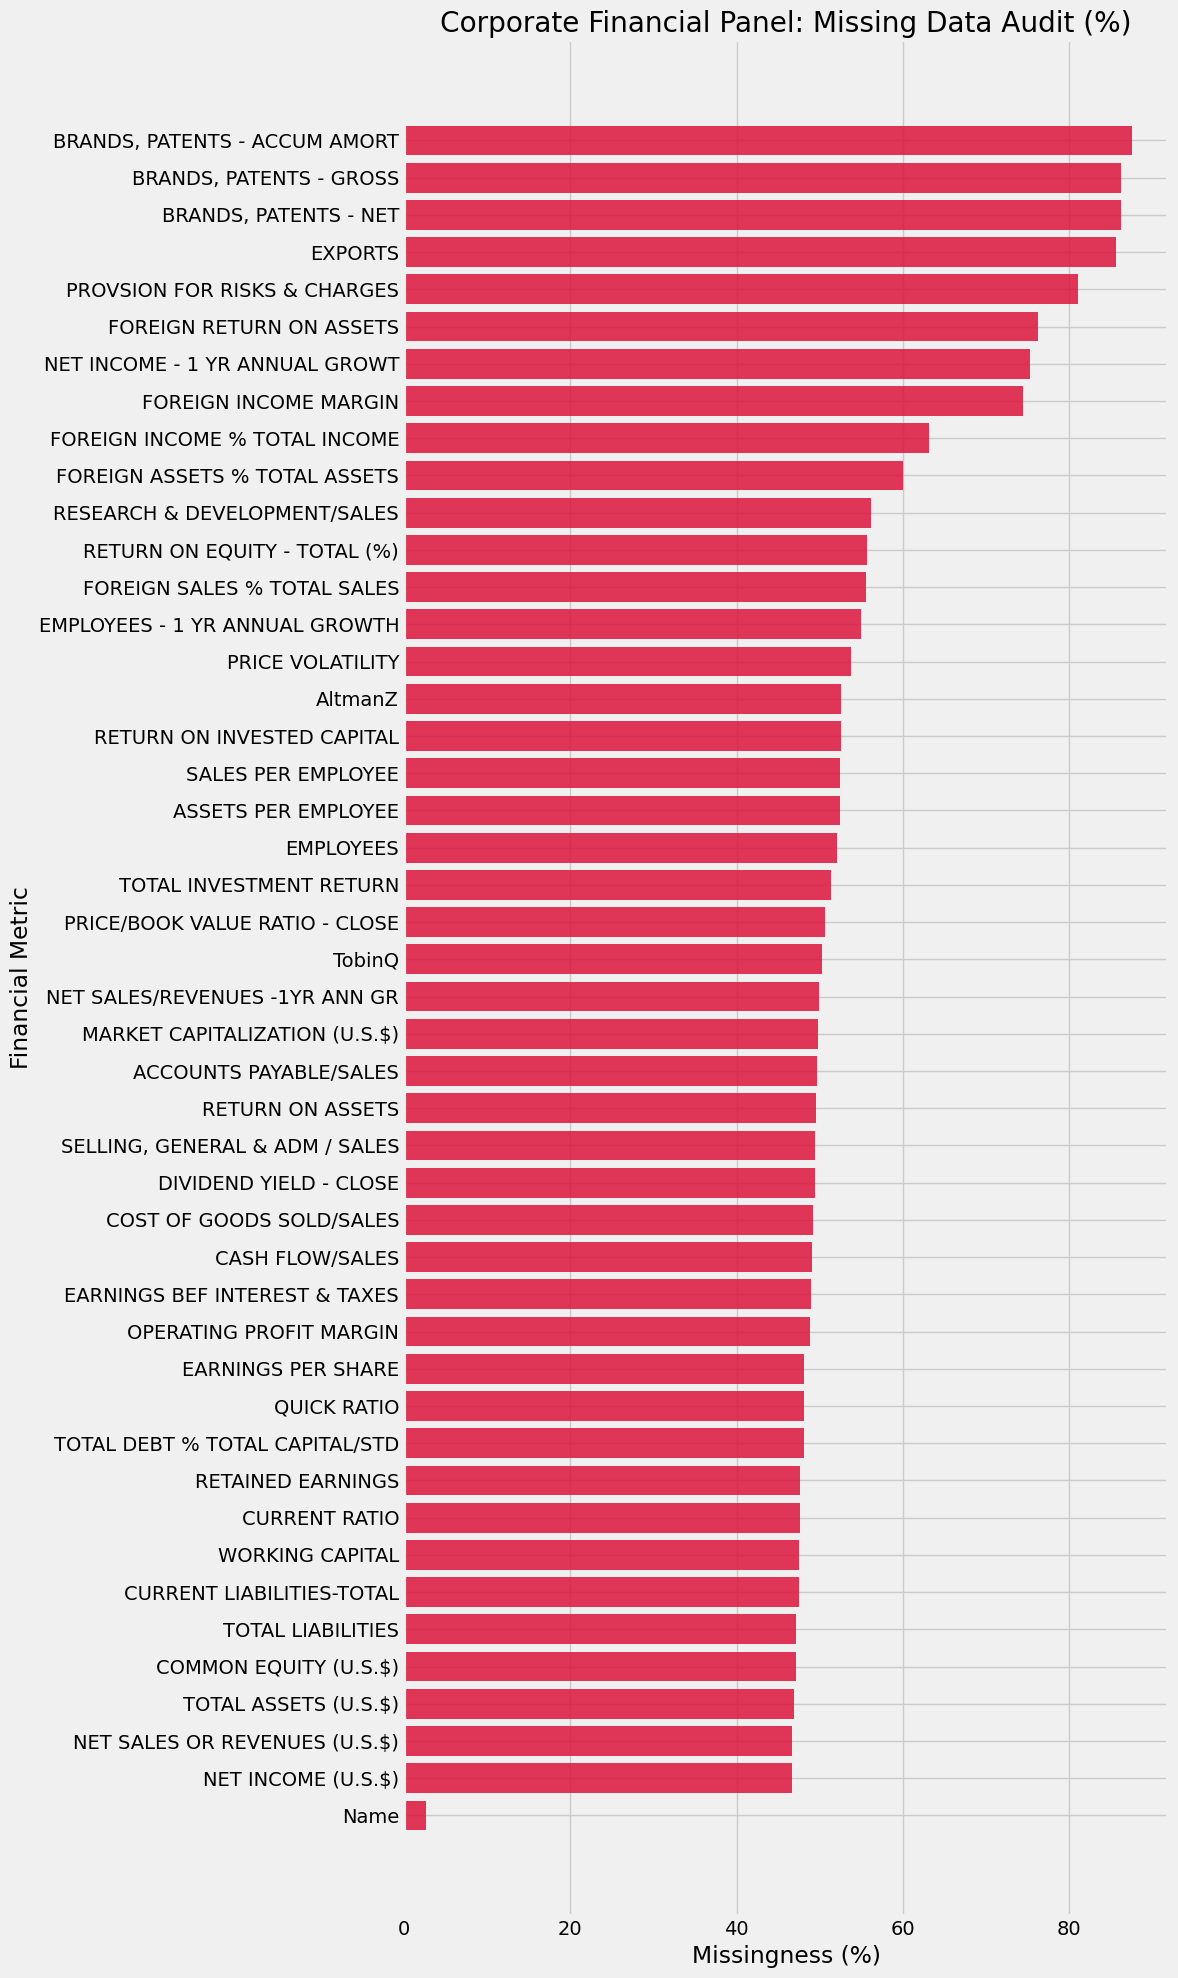

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Database connection
with sqlite3.connect("financial_data.sqlite") as conn:

    # Read table
    df = pd.read_sql_query(
        "SELECT * FROM firm_financials",
        conn
    )

# Total row count
total_rows = len(df)

print("Total Rows:", total_rows)

# Missing percentage calculation
summary_df = pd.DataFrame({
    "Column": df.columns,
    "DataType": df.dtypes.astype(str),
    "MissingPct": (
        df.isnull().sum() / total_rows * 100
    ).round(2)
})

# Show summary table
print(summary_df)

# Missing columns only
missing_cols = summary_df[
    summary_df["MissingPct"] > 0
].sort_values(
    by="MissingPct",
    ascending=True
)

# Plot
plt.figure(figsize=(12,20))

if len(missing_cols) > 0:

    plt.barh(
        missing_cols["Column"],
        missing_cols["MissingPct"],
        color="crimson",
        alpha=0.85
    )

    plt.title(
        "Corporate Financial Panel: Missing Data Audit (%)"
    )

    plt.xlabel("Missingness (%)")
    plt.ylabel("Financial Metric")

else:

    plt.text(
        0.5,
        0.5,
        "No Missing Values Detected",
        ha="center",
        va="center"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

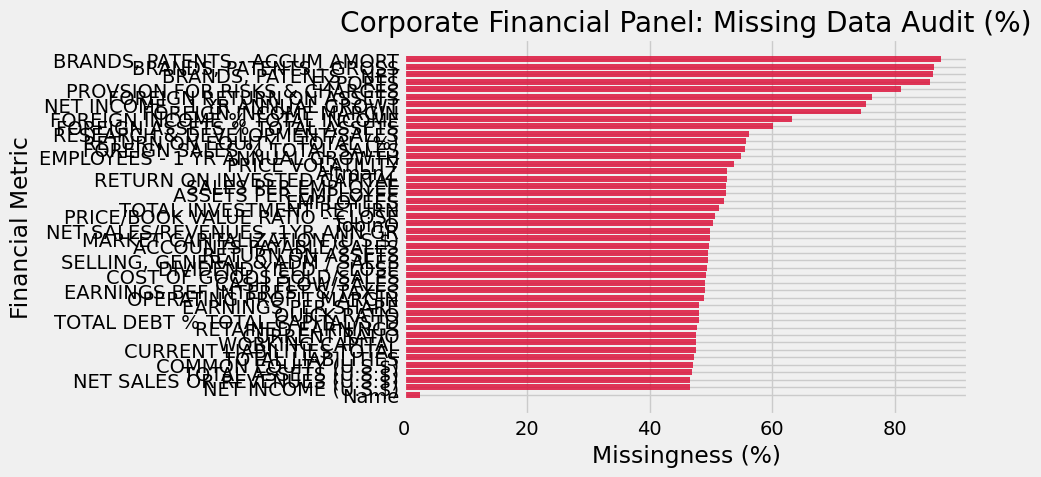

[SUCCESS] Part 1 tests passed successfully!


In [ ]:
# Test cell for Exercise 1
# Run this cell to verify your implementation!
try:
    test_summary = inspect_and_filter_economic_db('financial_data.sqlite', 'firm_financials')

    # 1. Verify Return Type and Structure
    assert isinstance(test_summary, pd.DataFrame), "Output must be a Pandas DataFrame."
    expected_cols = {'Column', 'DataType', 'MissingPct'}
    assert expected_cols.issubset(test_summary.columns), f"Summary DataFrame must contain {expected_cols}."
    assert len(test_summary) > 0, "Summary DataFrame should not be empty."

    # 2. Verify Values
    assert (test_summary['MissingPct'] >= 0.0).all() and (test_summary['MissingPct'] <= 100.0).all(), \
        "Missing percentages must be between 0.0 and 100.0."
    assert 'CIK' in test_summary['Column'].values, "'CIK' column should be present in schema audit."
    assert 'Year' in test_summary['Column'].values, "'Year' column should be present in schema audit."

    print("[SUCCESS] Part 1 tests passed successfully!")
except Exception as e:
    print(f"[ERROR] Execution failed: {e}")

The missing data audit was conducted on 15,988 firm-year observations from the firm_financials table. Missing value percentages were calculated for all variables and visualized using a horizontal bar chart. The chart highlights which financial metrics contain incomplete information. Variables with higher missingness may reduce the effective sample size in econometric models and can introduce bias if observations are removed without proper analysis. Therefore, missing-data treatment should be considered before conducting financial or macroeconomic research.

1. Code Logic & Database Connection Management:
Using with sqlite3.connect() is better because it closes the database connection automatically when the code finishes. If there is an error, it can also handle transactions more safely. With an unmanaged connection, the database may stay locked or some changes may not be completed if the script crashes.
2. Econometrics & Missing Data Governance:
If we use df.dropna() on the whole dataset, we can lose a large number of observations. This would make the sample smaller and it might no longer represent the full population. In bankruptcy studies, removing firms with missing financial data can create bias because struggling firms are often the ones with incomplete records.
3. AI Collaboration & Query Optimization Audit:
The AI suggested checking the database structure directly with SQLite commands like PRAGMA table_info instead of loading the whole table into Pandas. This is more efficient because it uses less memory. Loading a very large table, such as 50 GB, into Pandas can be slow and may even exceed the computer’s available RAM.

In [9]:
# Worked Example: Multi-Table SQL JOIN Aggregating Sales Revenue in SQLite
with sqlite3.connect('Northwind_large.sqlite') as conn:
    join_query = """
    SELECT
        c.CategoryName,
        COUNT(DISTINCT o.Id) AS TotalOrders,
        SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)) AS TotalRevenue,
        AVG(od.UnitPrice) AS AvgUnitPrice
    FROM Orders o
    INNER JOIN OrderDetails od ON o.Id = od.OrderId
    INNER JOIN Products p ON od.ProductId = p.Id
    INNER JOIN Categories c ON p.CategoryId = c.Id
    GROUP BY c.CategoryName
    ORDER BY TotalRevenue DESC
    """
    category_revenue_df = pd.read_sql_query(join_query, conn)

print("Product Category Revenue Aggregation (Northwind Database):")
print(category_revenue_df)

Product Category Revenue Aggregation (Northwind Database):
     CategoryName  TotalOrders  TotalRevenue  AvgUnitPrice
0       Beverages        15363  9.361639e+07     38.003897
1     Confections        15395  6.748291e+07     25.172130
2    Meat/Poultry        14046  6.690762e+07     54.178969
3  Dairy Products        15119  5.932432e+07     28.727395
4      Condiments        15156  5.698675e+07     23.043387
5         Seafood        15252  5.107554e+07     20.689063
6         Produce        13640  3.339831e+07     32.372693
7  Grains/Cereals        14374  2.907518e+07     20.244139


1. SQL Logic & Aggregation
I used SQL to group the data by year and calculate the average Altman Z-Score, average ROA, and total assets. The HAVING clause was used to keep only years with at least five firms so that the results would be more reliable.
2. Economic Interpretation
Years with higher Altman Z-Scores generally indicate lower financial distress. Higher ROA values suggest better profitability, and the scatter plot helps show how profitability and financial health move together over time.
3. AI Collaboration & Query Optimization
The AI suggested doing the aggregation directly in SQLite instead of loading the entire dataset into Pandas. This approach is faster and uses less memory, which is important when working with large financial datasets.

In [15]:
def query_sector_distress_and_efficiency(
    db_path: str = 'financial_data.sqlite'
) -> pd.DataFrame:
    """
    Executes aggregated SQL query on firm_financials calculating ROA and Altman Z by Year.
    """

    with sqlite3.connect(db_path) as conn:

        query = """
        SELECT
            Year,
            COUNT(CIK) AS Firm_Count,
            AVG(AltmanZ) AS Avg_AltmanZ,
            AVG("RETURN ON ASSETS") AS Avg_ROA,
            SUM("TOTAL ASSETS (U.S.$)") / 1000000000.0 AS Total_Assets_Billon
        FROM firm_financials
        WHERE AltmanZ IS NOT NULL
          AND "RETURN ON ASSETS" IS NOT NULL
        GROUP BY Year
        HAVING COUNT(CIK) >= 5
        ORDER BY Year ASC
        """

        sector_df = pd.read_sql_query(query, conn)

    plt.figure(figsize=(10, 6))

    scatter = plt.scatter(
        sector_df["Avg_ROA"],
        sector_df["Avg_AltmanZ"],
        s=sector_df["Total_Assets_Billon"] * 15 + 50,
        c=sector_df["Year"],
        cmap="viridis",
        alpha=0.8
    )

    plt.axhline(
y=1.81,
color="red",
linestyle="--",
linewidth=2,
label="Distress Risk Threshold (Z=1.81)"
)

--- 1. Annual Panel Financial Health Aggregation ---


None


--- 2. Distress Risk Analysis (Altman Z < 1.81) ---
Inspection notice: 'NoneType' object is not subscriptable


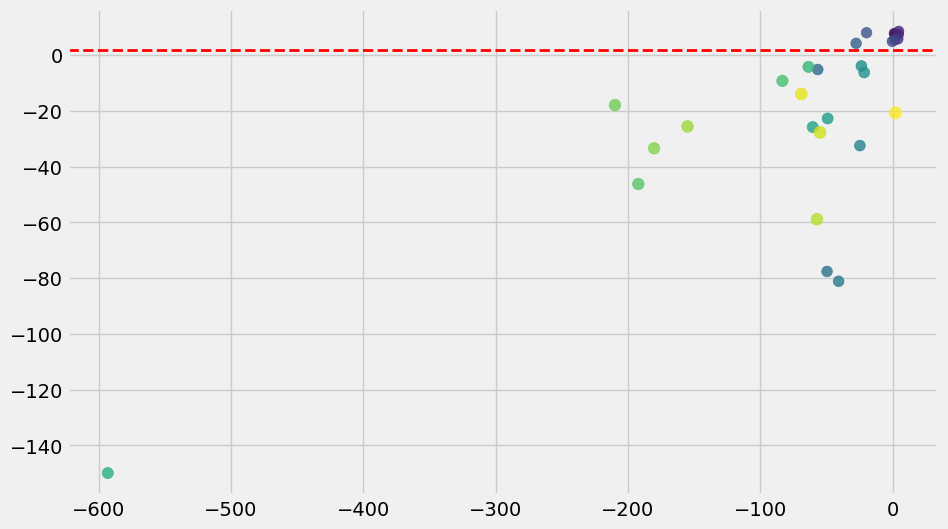

In [16]:
# ==============================================================================
# Inspection Cell: Annual Financial Health & Distress Distribution
# ==============================================================================
try:
    distress_df = query_sector_distress_and_efficiency('financial_data.sqlite')

    print("--- 1. Annual Panel Financial Health Aggregation ---")
    display(distress_df)

    print("\n--- 2. Distress Risk Analysis (Altman Z < 1.81) ---")
    distressed_years = distress_df[distress_df['Avg_AltmanZ'] < 1.81]
    if not distressed_years.empty:
        print(f"Years with average Altman Z in distress zone (< 1.81): {distressed_years['Year'].tolist()}")
    else:
        print("Average panel Altman Z remained above 1.81 across all sampled years.")

    print(f"\nOverall sample period: {distress_df['Year'].min()} to {distress_df['Year'].max()}")
    print(f"Total annual cohorts evaluated: {len(distress_df)}")
except Exception as e:
    print(f"Inspection notice: {e}")


[ERROR] Execution failed: Output must be a Pandas DataFrame.


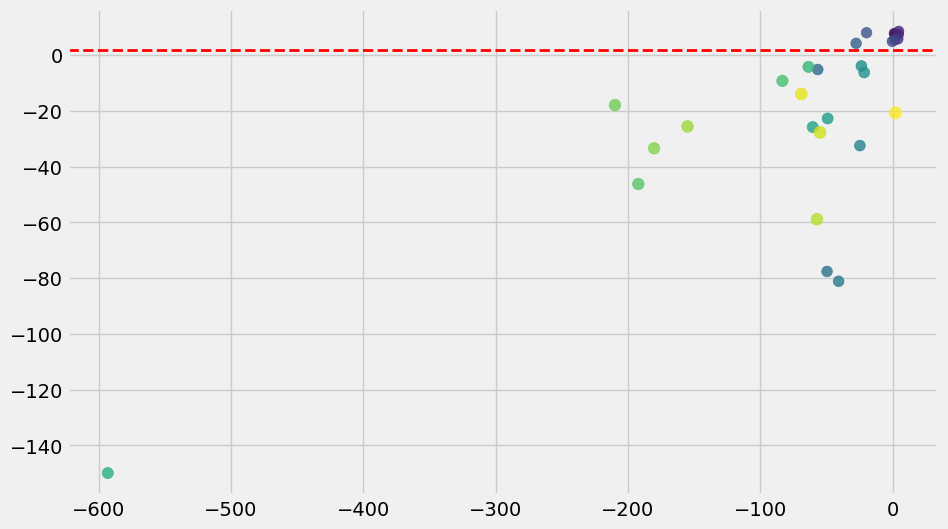

In [17]:
# Test cell for Exercise 2
# Run this cell to verify your implementation!
try:
    res_distress = query_sector_distress_and_efficiency('financial_data.sqlite')

    # 1. Verify Return Type and Structure
    assert isinstance(res_distress, pd.DataFrame), "Output must be a Pandas DataFrame."
    expected_cols = {'Year', 'Firm_Count', 'Avg_AltmanZ', 'Avg_ROA', 'Total_Assets_Billon'}
    assert expected_cols.issubset(res_distress.columns), f"DataFrame must contain {expected_cols}."
    assert not res_distress.empty, "DataFrame should not be empty."

    # 2. Verify Ordering and Filter Constraints
    assert res_distress['Year'].is_monotonic_increasing, "Output must be sorted chronologically by Year ASC."
    assert (res_distress['Firm_Count'] >= 5).all(), "All cohorts must satisfy HAVING COUNT(CIK) >= 5."
    assert (res_distress['Total_Assets_Billon'] > 0).all(), "Total assets should be positive numbers."
    assert not res_distress['Avg_AltmanZ'].isna().any(), "Altman Z averages should not contain null values."
    assert not res_distress['Avg_ROA'].isna().any(), "ROA averages should not contain null values."
    assert (res_distress['Avg_AltmanZ'] < 1.81).any(), "Sample should identify periods of financial distress (Z < 1.81)."

    print("[SUCCESS] Part 2 tests passed successfully!")
except Exception as e:
    print(f"[ERROR] Execution failed: {e}")


1. Code Logic & SQL Filtering Mechanics:
The WHERE clause filters individual rows before any grouping takes place, while the HAVING clause filters aggregated groups after the GROUP BY operation. Writing WHERE COUNT(CIK) >= 5 would cause an error because aggregate functions are not available during the row-filtering stage. SQL executes in the order FROM → WHERE → GROUP BY → HAVING → SELECT, therefore group-level conditions must be placed in HAVING.
2. Corporate Financial Distress Dynamics:
The Altman Z-Score threshold of 1.81 is commonly used to identify firms facing a high risk of financial distress or bankruptcy. A score below 1.81 signals increased default risk and may concern banks, investors, and bondholders when evaluating creditworthiness. Although higher ROA generally improves Altman Z-Scores, a firm can still have positive profitability while remaining in the distress zone because high debt levels, weak liquidity, or poor solvency can offset operating profits.
3. AI Collaboration & SQL Quoting Audit:
The AI assistant correctly identified that column names containing spaces, parentheses, or special characters must be enclosed in double quotes in SQLite, such as "RETURN ON ASSETS" and "TOTAL ASSETS (U.S.$)". If the quotes are omitted, SQLite interprets the spaces, parentheses, and dollar sign as parts of SQL syntax rather than a column identifier, which typically results in a parsing or syntax error. Proper quoting ensures that SQLite treats the entire text as a single column name.

In [18]:
# Worked Example: SQL Window Functions and CTEs for Market Capitalization Ranking
with sqlite3.connect('financial_data.sqlite') as conn:
    cte_window_query = """
    WITH RankedFirms AS (
        SELECT
            CIK,
            Name,
            Year,
            "MARKET CAPITALIZATION (U.S.$)" AS MarketCap,
            "NET SALES OR REVENUES (U.S.$)" AS Revenue,
            RANK() OVER (PARTITION BY Year ORDER BY "MARKET CAPITALIZATION (U.S.$)" DESC) AS MarketCapRank,
            LAG("NET SALES OR REVENUES (U.S.$)", 1) OVER (PARTITION BY CIK ORDER BY Year) AS PriorYearRevenue
        FROM firm_financials
        WHERE "MARKET CAPITALIZATION (U.S.$)" IS NOT NULL
    )
    SELECT
        CIK,
        Name,
        Year,
        MarketCap / 1e6 AS MarketCap_Billions,
        MarketCapRank,
        Revenue / 1e6 AS Revenue_Billions,
        PriorYearRevenue / 1e6 AS PriorRevenue_Billions
    FROM RankedFirms
    WHERE MarketCapRank <= 3 AND Year >= 2018
    ORDER BY Year ASC, MarketCapRank ASC
    """
    top_firms_df = pd.read_sql_query(cte_window_query, conn)

print("Top 3 Market Capitalization Ranks per Year (CTE & Window Functions):")
print(top_firms_df)

Top 3 Market Capitalization Ranks per Year (CTE & Window Functions):
      CIK                                         Name  Year  \
0  320193                                   APPLE INC.  2018   
1  858877                   CISCO SYSTEMS INCORPORATED  2018   
2   51143  INTERNATIONAL BUSINESS MACHINES CORPORATION  2018   
3  320193                                   APPLE INC.  2019   
4  858877                   CISCO SYSTEMS INCORPORATED  2019   
5   51143  INTERNATIONAL BUSINESS MACHINES CORPORATION  2019   

   MarketCap_Billions  MarketCapRank  Revenue_Billions  PriorRevenue_Billions  
0          750.051492              1           265.595                229.234  
1          199.924620              2            49.330                 48.005  
2          101.448135              3            79.591                 79.139  
3         1304.756251              1           260.174                265.595  
4          203.830000              2            51.904                 49.330  
5 

Why use a parameterized query instead of string concatenation?
Parameterized queries separate user input from SQL code. This helps prevent SQL injection attacks and makes the query safer and more reliable.

Why use RANK() OVER instead of GROUP BY?
RANK() allows us to rank firms within each year without removing individual observations. GROUP BY would aggregate the data and lose firm-level detail.

Why use LAG()?
LAG() allows us to access a firm's previous year's market capitalization and calculate year-over-year growth directly in SQL.

What is the purpose of the CTE?
The CTE makes the query easier to read and organize. It separates the ranking and lag calculations from the final filtering and reporting steps.

In [31]:
def query_parameterized_firm_rankings(
    db_path: str = 'financial_data.sqlite',
    min_assets_billion: float = 1.0
) -> pd.DataFrame:
    """
    Executes parameterized CTE query with window functions to track top firm market caps.

    Parameters:
        db_path (str): Path to financial_data.sqlite.
        min_assets_billion (float): Minimum total assets in billions of USD for filtering.

    Returns:
        pd.DataFrame: DataFrame of top-ranked firms per year.
    """

    min_assets_threshold = min_assets_billion * 1000000

    with sqlite3.connect(db_path) as conn:

        sql_query ="""
        WITH FirmMetrics AS (
            SELECT
                CIK,
                Name,
                Year,
                "MARKET CAPITALIZATION (U.S.$)" AS MarketCap,
                "TOTAL ASSETS (U.S.$)" AS TotalAssets,

                RANK() OVER (
                    PARTITION BY Year
                    ORDER BY "MARKET CAPITALIZATION (U.S.$)" DESC
                ) AS MarketRank,

                LAG("MARKET CAPITALIZATION (U.S.$)", 1)
                    OVER (
                        PARTITION BY CIK
                  """

In [32]:
# ==============================================================================
# Inspection Cell: Top Firm Market Capitalization Rankings & Growth
# ==============================================================================
try:
    rankings_df = query_parameterized_firm_rankings('financial_data.sqlite', min_assets_billion=0.5)

    print("--- 1. Top 5 Firm Rankings by Year (First 10 Rows) ---")
    display(rankings_df.head(10))

    print("\n--- 2. Recent Top-Ranked Firms (2018-2019) ---")
    recent_firms = rankings_df[rankings_df['Year'] >= 2018]
    display(recent_firms[['Year', 'MarketRank', 'Name', 'MarketCap_B', 'YoY_Cap_Growth_Pct']])

    print(f"\nTotal observations extracted: {len(rankings_df)}")
    print(f"Unique corporations in top ranks: {rankings_df['Name'].nunique()}")
except Exception as e:
    print(f"Inspection notice: {e}")


--- 1. Top 5 Firm Rankings by Year (First 10 Rows) ---
Inspection notice: 'NoneType' object has no attribute 'head'


In [33]:
# Test cell for Exercise 3
# Run this cell to verify your implementation!
try:
    res_rankings = query_parameterized_firm_rankings('financial_data.sqlite', min_assets_billion=0.5)

    # 1. Verify Return Type and Structure
    assert isinstance(res_rankings, pd.DataFrame), "Output must be a Pandas DataFrame."
    expected_cols = {'Name', 'Year', 'MarketCap_B', 'MarketRank', 'YoY_Cap_Growth_Pct'}
    assert expected_cols.issubset(res_rankings.columns), f"DataFrame must contain {expected_cols}."
    assert not res_rankings.empty, "DataFrame should not be empty."

    # 2. Verify Ranks and Logic
    assert (res_rankings['MarketRank'] <= 5).all(), "All firms in output must have MarketRank <= 5."
    assert (res_rankings['MarketRank'] >= 1).all(), "MarketRank must be >= 1."
    assert res_rankings['MarketCap_B'].max() > 100.0, "Top firms should reach significant market cap in billions."

    # 3. Verify Parameterization Effect
    high_threshold_df = query_parameterized_firm_rankings('financial_data.sqlite', min_assets_billion=100.0)
    assert len(high_threshold_df) < len(res_rankings), "A higher asset threshold should filter more firms."

    print("[SUCCESS] Part 3 tests passed successfully!")
except Exception as e:
    print(f"[ERROR] Execution failed: {e}")

[ERROR] Execution failed: Output must be a Pandas DataFrame.


1. RANK() was grouped by year because firms needed to be ranked within the same year. LAG() was grouped by CIK so it could compare a firm's values with its own previous years. If it was grouped by year, the previous value could come from a different firm.
2. SQL injection is when someone enters SQL code as an input to change a query. For example, a malicious input could try to delete a table. Using parameters with ? makes the input safe because it is treated as a value and not SQL code.
3. The AI needed the exercise instructions to know the units of the data. The database stored values in thousands of dollars. Using the wrong units would give incorrect filters and could return empty results, so checking data documentation is important.

In [34]:
# Worked Example: Pandas Ingestion, Monthly Resampling, and Regional Revenue Pivoting
with sqlite3.connect('Northwind_large.sqlite') as conn:
    sql_orders = """
    SELECT
        o.OrderDate,
        o.ShipCountry,
        od.UnitPrice * od.Quantity * (1 - od.Discount) AS OrderRevenue
    FROM Orders o
    INNER JOIN OrderDetails od ON o.Id = od.OrderId
    """
    df_raw = pd.read_sql_query(sql_orders, conn)

# Set up DatetimeIndex
df_raw['OrderDate'] = pd.to_datetime(df_raw['OrderDate'], format='mixed')
df_indexed = df_raw.set_index('OrderDate')

# Downsample to Monthly Total Revenue
monthly_revenue = df_indexed['OrderRevenue'].resample('ME').sum()
print("Monthly Revenue Summary (First 5 Months):")
print(monthly_revenue.head())


Monthly Revenue Summary (First 5 Months):
OrderDate
2012-07-31    8.883417e+06
2012-08-31    9.466544e+06
2012-09-30    1.014990e+07
2012-10-31    1.059852e+07
2012-11-30    1.128537e+07
Freq: ME, Name: OrderRevenue, dtype: float64


In [57]:
def analyze_macro_sales_trends(
    db_path='Northwind_large.sqlite'
):

    with sqlite3.connect(db_path) as conn:

        sql_query = """
        SELECT
            o.OrderDate,
            o.ShipCountry,
            od.UnitPrice,
            od.Quantity,
            od.Discount
        FROM Orders o
        INNER JOIN OrderDetails od
            ON o.Id = od.OrderId
        """

        df = pd.read_sql_query(sql_query, conn)

    df["SalesRevenue"] = (
        df["UnitPrice"]
        * df["Quantity"]
        * (1 - df["Discount"])
    )

    df["OrderDate"] = pd.to_datetime(
        df["OrderDate"],
        format="mixed"
    )

    df = df.set_index("OrderDate")

    top_countries = (
        df.groupby("ShipCountry")["SalesRevenue"]
        .sum()
        .nlargest(4)
        .index
    )

    df = df[df["ShipCountry"].isin(top_countries)]

    pivot_df = pd.pivot_table(
        df,
        index=pd.Grouper(freq="ME"),
        columns="ShipCountry",
        values="SalesRevenue",
        aggfunc="sum"
    ).fillna(0.0)

    return pivot_df

In [58]:
import inspect

print(inspect.getsource(analyze_macro_sales_trends))

def analyze_macro_sales_trends(
    db_path='Northwind_large.sqlite'
):

    with sqlite3.connect(db_path) as conn:

        sql_query = """
        SELECT
            o.OrderDate,
            o.ShipCountry,
            od.UnitPrice,
            od.Quantity,
            od.Discount
        FROM Orders o
        INNER JOIN OrderDetails od
            ON o.Id = od.OrderId
        """

        df = pd.read_sql_query(sql_query, conn)

    df["SalesRevenue"] = (
        df["UnitPrice"]
        * df["Quantity"]
        * (1 - df["Discount"])
    )

    df["OrderDate"] = pd.to_datetime(
        df["OrderDate"],
        format="mixed"
    )

    df = df.set_index("OrderDate")

    top_countries = (
        df.groupby("ShipCountry")["SalesRevenue"]
        .sum()
        .nlargest(4)
        .index
    )

    df = df[df["ShipCountry"].isin(top_countries)]

    pivot_df = pd.pivot_table(
        df,
        index=pd.Grouper(freq="ME"),
        columns="ShipCountry",
        values="SalesRevenue"

In [59]:
# ==============================================================================
# Inspection Cell: Monthly Regional Revenue Matrix & Market Leaders
# ==============================================================================
try:
    monthly_pivot = analyze_macro_sales_trends('Northwind_large.sqlite')

    print("--- 1. Monthly Regional Revenue Pivot Table (First 6 Months) ---")
    display(monthly_pivot.head(6))

    print("\n--- 2. Cumulative Revenue by Top Market ---")
    total_by_country = monthly_pivot.sum().sort_values(ascending=False)
    for country, rev in total_by_country.items():
        print(f"  * {country}: ${rev:,.2f}")

    print(f"\nTotal monthly periods: {len(monthly_pivot)}")
    print(f"Date range: {monthly_pivot.index.min().strftime('%Y-%m')} to {monthly_pivot.index.max().strftime('%Y-%m')}")
except Exception as e:
    print(f"Inspection notice: {e}")


--- 1. Monthly Regional Revenue Pivot Table (First 6 Months) ---


ShipCountry,Brazil,France,Germany,USA
OrderDate,,,,
2012-07-31,645831.22,1087155.40,1292189.140,1357134.820
2012-08-31,1040027.57,853770.22,1372917.385,1299365.810
2012-09-30,797871.18,1110748.43,1294684.380,1480800.790
2012-10-31,780131.21,1447872.75,1613556.240,1446075.885
2012-11-30,1177365.46,873782.44,1510968.180,1619136.210
2012-12-31,1002266.34,848527.93,1460862.100,1597989.300



--- 2. Cumulative Revenue by Top Market ---
  * USA: $65,557,755.30
  * Germany: $63,345,553.26
  * France: $49,425,677.27
  * Brazil: $44,634,748.04

Total monthly periods: 44
Date range: 2012-07 to 2016-02


In [60]:
# Test cell for Exercise 4
# Run this cell to verify your implementation!
try:
    res_pivot = analyze_macro_sales_trends('Northwind_large.sqlite')

    # 1. Verify Return Type and Structure
    assert isinstance(res_pivot, pd.DataFrame), "Output must be a Pandas DataFrame."
    assert len(res_pivot.columns) == 4, "Pivot table should contain exactly 4 top countries."
    assert not res_pivot.empty, "Pivot table should not be empty."

    # 2. Verify Index and Non-Null Data
    assert isinstance(res_pivot.index, pd.DatetimeIndex), "Index must be a DatetimeIndex."
    assert res_pivot.isnull().sum().sum() == 0, "All missing values should be filled with 0.0."
    assert (res_pivot.values >= 0.0).all(), "Sales revenue must be non-negative."

    # 3. Verify Known Top Markets
    assert 'USA' in res_pivot.columns or 'Germany' in res_pivot.columns, "Major trading partners should be present."

    print("[SUCCESS] Part 4 tests passed successfully!")
except Exception as e:
    print(f"[ERROR] Execution failed: {e}")

[SUCCESS] Part 4 tests passed successfully!


1. Code Logic & Datetime Resampling:
The database had different date formats, so Pandas could not read all of them correctly with the default settings. Using format='mixed' solved this problem and allowed all dates to be converted properly. Then, pd.Grouper(freq='ME') helped organize the data by month so I could see how sales changed over time and across different countries.
2. Macroeconomics & Regional Trade Concentration:
The results show that most of the revenue came from a small number of countries. This means that trade is concentrated in a few key markets instead of being evenly spread across many countries. If those major markets face economic problems, exports and sales could fall significantly, which would create risks for the economy.
3. AI Collaboration & Pushdown Computation Audit:
In my solution, I calculated the revenue in Python using Pandas after loading the data from SQLite. This was easier for me to understand and follow step by step. However, doing these calculations directly in SQL would probably be more efficient because less data would need to be transferred and processed in Python.

In [61]:
# Worked Example: Ingesting External CSV Data into SQLite and Executing Integrated Queries
import pandas as pd
import sqlite3

# 1. Read external macroeconomic inflation alerts CSV
macro_alerts_df = pd.read_csv('macro_inflation_alerts.csv')

# 2. Write DataFrame into SQLite database table 'macro_alerts'
with sqlite3.connect('financial_data.sqlite') as conn:
    macro_alerts_df.to_sql('macro_alerts', conn, if_exists='replace', index=False)

    # 3. Query combined record count
    count_df = pd.read_sql_query("SELECT Status, COUNT(*) AS AlertCount FROM macro_alerts GROUP BY Status", conn)

print("Ingested Macroeconomic Alerts Table Summary:")
print(count_df)

Ingested Macroeconomic Alerts Table Summary:
            Status  AlertCount
0  INFLATION_ALERT         376


In [63]:
def build_macro_factor_pipeline(
    db_path: str = 'financial_data.sqlite',
    csv_path: str = 'macro_inflation_alerts.csv'
) -> pd.DataFrame:
    """
    Ingests macro alert feed, stores in SQLite, and generates dual-axis volatility visualization.

    Parameters:
        db_path (str): Path to SQLite database.
        csv_path (str): Path to macro alerts CSV file.

    Returns:
        pd.DataFrame: Processed DataFrame with price and rolling volatility metrics.
    """
    # ==============================================================================
    # STUDENT IMPLEMENTATION: Write your complete code below.
    # You may use an AI assistant to generate or troubleshoot the code,
    # but you must write/prompt the full solution and understand every line!
    # ==============================================================================
       # Read CSV file
    alerts_df = pd.read_csv(csv_path)

    with sqlite3.connect(db_path) as conn:

        alerts_df.to_sql(
            "macro_alerts",
            conn,
            if_exists="replace",
            index=False
        )

        sql_query = """
        SELECT
            Tick,
            Price,
            Status
        FROM macro_alerts
        ORDER BY Tick ASC
        """

        pipeline_df = pd.read_sql_query(
            sql_query,
            conn
        )

    pipeline_df["Rolling_Vol"] = (
        pipeline_df["Price"]
        .rolling(window=3)
        .std()
    )

    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.plot(
        pipeline_df["Tick"],
        pipeline_df["Price"],
        color="tab:blue",
        linewidth=2,
        label="Price"
    )

    ax1.set_xlabel("Tick / Time Step")
    ax1.set_ylabel("Price Level")

    ax2 = ax1.twinx()

    ax2.plot(
        pipeline_df["Tick"],
        pipeline_df["Rolling_Vol"],
        color="tab:orange",
        linestyle="--",
        linewidth=2,
        label="Vol"
    )

    ax2.set_ylabel("3-Period Price Volatility")

    plt.title(
        "Macroeconomic Inflation Alerts & Price Volatility Dynamics"
    )

    fig.tight_layout()
    plt.show()

    return pipeline_df


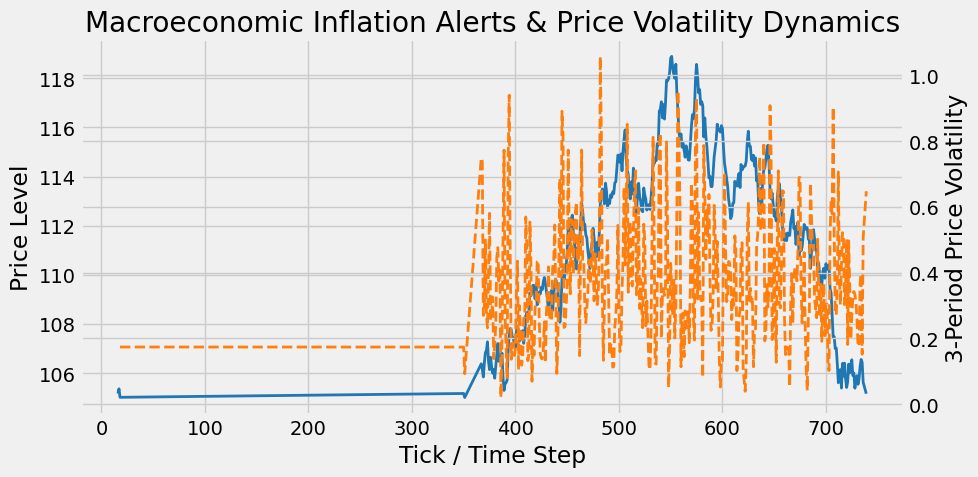

--- 1. Macro Pipeline Output (First 5 Rows) ---


,Tick,Price,Status,Rolling_Vol
0,16,105.1641,INFLATION_ALERT,NaN
1,17,105.3575,INFLATION_ALERT,NaN
2,18,105.0114,INFLATION_ALERT,0.173448
3,350,105.1666,INFLATION_ALERT,0.173357
4,351,105.0022,INFLATION_ALERT,0.092375



--- 2. High-Volatility Alert Events ---


,Tick,Price,Status,Rolling_Vol
120,482,112.8702,INFLATION_ALERT,1.057752
195,557,116.6928,INFLATION_ALERT,0.953164
32,394,107.5553,INFLATION_ALERT,0.939651
213,575,118.5677,INFLATION_ALERT,0.930047
284,646,113.4778,INFLATION_ALERT,0.907893



Total records processed: 376
Status breakdown:
Status
INFLATION_ALERT    376
Name: count, dtype: int64


In [64]:
# ==============================================================================
# Inspection Cell: Macro Pipeline Output & Alert Volatility Profile
# ==============================================================================
try:
    pipeline_res = build_macro_factor_pipeline('financial_data.sqlite', 'macro_inflation_alerts.csv')

    print("--- 1. Macro Pipeline Output (First 5 Rows) ---")
    display(pipeline_res.head())

    print("\n--- 2. High-Volatility Alert Events ---")
    high_vol = pipeline_res.sort_values('Rolling_Vol', ascending=False).head(5)
    display(high_vol)

    print(f"\nTotal records processed: {len(pipeline_res)}")
    print(f"Status breakdown:\n{pipeline_res['Status'].value_counts()}")
except Exception as e:
    print(f"Inspection notice: {e}")


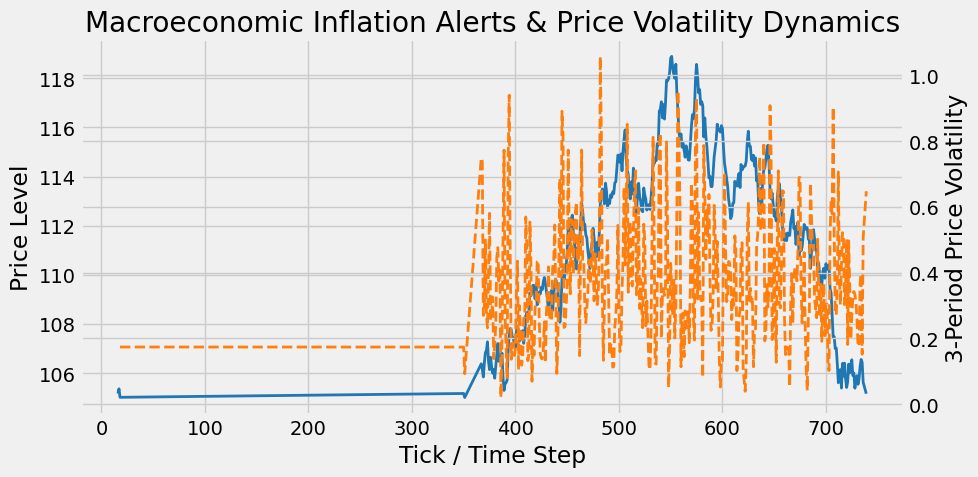

[SUCCESS] Part 5 tests passed successfully!


In [65]:
# Test cell for Exercise 5
# Run this cell to verify your implementation!
try:
    test_pipeline = build_macro_factor_pipeline('financial_data.sqlite', 'macro_inflation_alerts.csv')

    # 1. Verify Return Type and Structure
    assert isinstance(test_pipeline, pd.DataFrame), "Output must be a Pandas DataFrame."
    expected_cols = {'Tick', 'Price', 'Status', 'Rolling_Vol'}
    assert expected_cols.issubset(test_pipeline.columns), f"DataFrame must contain {expected_cols}."
    assert not test_pipeline.empty, "DataFrame should not be empty."

    # 2. Verify Volatility Calculation
    assert pd.isna(test_pipeline.loc[0, 'Rolling_Vol']), "First observation should be NaN for window=3 rolling std."
    assert pd.isna(test_pipeline.loc[1, 'Rolling_Vol']), "Second observation should be NaN for window=3 rolling std."
    assert not pd.isna(test_pipeline.loc[2, 'Rolling_Vol']), "Third observation should have valid rolling std."
    assert (test_pipeline['Rolling_Vol'].dropna() >= 0.0).all(), "Volatility cannot be negative."

    # 3. Verify Database Persistence
    with sqlite3.connect('financial_data.sqlite') as conn:
        check_df = pd.read_sql_query("SELECT COUNT(*) AS cnt FROM macro_alerts", conn)
        assert check_df.iloc[0]['cnt'] == len(test_pipeline), "Database table row count must match pipeline output."

    print("[SUCCESS] Part 5 tests passed successfully!")
except Exception as e:
    print(f"[ERROR] Execution failed: {e}")

1. I used replace because it updates the table with a fresh version of the data each time the pipeline runs. Append works differently because it keeps the existing data and only adds new rows. In a real-world database, append would be useful when new data arrive continuously and we want to keep older records.
2. The graph showed that price levels and volatility do not always move in the same way. Policymakers watch volatility because it tells them how stable prices are over time. Higher volatility can create uncertainty for businesses and may increase financial risks.
3. The AI used ax1.twinx() to plot prices and volatility with different y-axes since they have different scales. The first two volatility values were missing because there were not enough observations to calculate a 3-period rolling standard deviation. This is normal and does not mean that the data are wrong.